In [4]:
import pandas as pd
import numpy as np
import networkx as nx
import os
from scipy.io import mmread, loadmat
from small_world_propensity import SWP
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import sparse
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler

In [2]:
fc = np.load('/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/100206/symmetrized/covariance_symmetrized.npy')
sc = np.load('/home/gbz6qn/Documents/research/data/hcp_shen_sc/sub-100206_parc-shen268_tract-prob_sc.npy')

In [3]:
spi_dir = '/home/gbz6qn/Documents/research/data/coupling/working/included_subs/spis/'
sc_dir = '/home/gbz6qn/Documents/research/data/hcp_shen_sc/'
# List of subs
with open('/home/gbz6qn/Documents/research/code/coupling/compute_gca/subs.txt', 'r') as f:
    lines = f.read()
    subs = lines.split('\n')[:-1]
subs = sorted(subs)

## Thresholding by only retaining edges that also exist in the structural connectivity matrix

In [46]:
SWP_cov = []
delta_C_cov = []
delta_L_cov = []

for i, sub in tqdm(enumerate(subs)):
    fc_path = os.path.join(spi_dir, sub, 'symmetrized', 'covariance_symmetrized.npy')
    sc_path = os.path.join(sc_dir, f'sub-{sub}_parc-shen268_tract-prob_sc.npy')

    fc = np.load(fc_path)
    sc = np.load(sc_path)

    sparser = fc*(sc!=0)
    swp, delta_C, delta_L = SWP(sparser)
    SWP_cov.append(swp)
    delta_C_cov.append(delta_C)
    delta_L_cov.append(delta_L)

SWP_fc = np.array(SWP_cov)
SWP_fc = np.mean(SWP_fc[~np.isnan(SWP_fc)])
delta_C_fc = np.array(delta_C_cov)
delta_C_fc = np.mean(delta_C_fc[~np.isnan(delta_C_fc)])
delta_L_fc = np.array(delta_L_cov)
delta_L_fc = np.mean(delta_L_fc[~np.isnan(delta_L_fc)])

329it [03:53,  1.41it/s]


In [47]:
print(f'SWP: {SWP_fc:.3f}, delta_C: {delta_C_fc:.3f}, delta_L: {delta_L_fc}')

SWP: 0.585, delta_C: 0.311, delta_L: 0.4496801512197063


## Thresholding based on scaling to [0, 1] and taking various absolute thresholds

In [8]:
thresholds = [0.6, 0.5, 0.4, 0.3, 0.2]
results = {t: {'swp': [], 'delta_C': [], 'delta_L': []} for t in thresholds}
for i, sub in tqdm(enumerate(subs)):
    for threshold in thresholds:
        fc_path = os.path.join(spi_dir, sub, 'symmetrized', 'covariance_symmetrized.npy')
        fc = np.load(fc_path)
    
        # Scale
        fc_scaled = MinMaxScaler().fit_transform(fc)
        #Threshold at current value
        fc_thresh = np.where(fc_scaled >= threshold, fc_scaled, 0)

        swp, delta_C, delta_L = SWP(fc_thresh)
        results[threshold]['swp'].append(swp)
        results[threshold]['delta_C'].append(delta_C)
        results[threshold]['delta_L'].append(delta_L)

20it [01:27,  4.37s/it]


KeyboardInterrupt: 

In [9]:
results

{0.6: {'swp': [np.float64(0.73042548711876),
   np.float64(0.7744338258599698),
   np.float64(0.6191515026496178),
   np.float64(0.7982097473287957),
   np.float64(0.7727319061418251),
   np.float64(0.5517746294998495),
   np.float64(0.45627204320730597),
   np.float64(0.742318291515893),
   np.float64(0.454712599477059),
   np.float64(0.7150315857499038),
   np.float64(0.6919140003790154),
   np.float64(0.6756785398666648),
   np.float64(0.5081547096213104),
   np.float64(0.693112644958283),
   np.float64(0.7524441896128335),
   np.float64(0.6478499979602571),
   np.float64(0.8041565987243879),
   np.float64(0.7061215618463097),
   np.float64(0.5172011327477641),
   np.float64(0.7680576452851923),
   np.float64(0.7278248165418482)],
  'delta_C': [np.float64(0.3360246763313634),
   np.float64(0.27121927888351804),
   np.float64(0.0),
   np.float64(0.18324381589374678),
   np.float64(0.2357410619120951),
   np.float64(0.0),
   np.float64(0.0),
   np.float64(0.05009212517146388),
   np.f

In [25]:
def threshold(data, thresh=20):
    threshold = np.percentile(np.abs(data), q=thresh)
    data_thresh = np.where(np.abs(data) >= threshold, data, 0)
    return data_thresh

In [26]:
foo = threshold(fc)

In [35]:
sc_binary = np.where(sc > 0, 1, 0)
foo = fc * sc_binary

In [36]:
G = nx.Graph(foo)
nx.is_connected(G)

True

<Axes: >

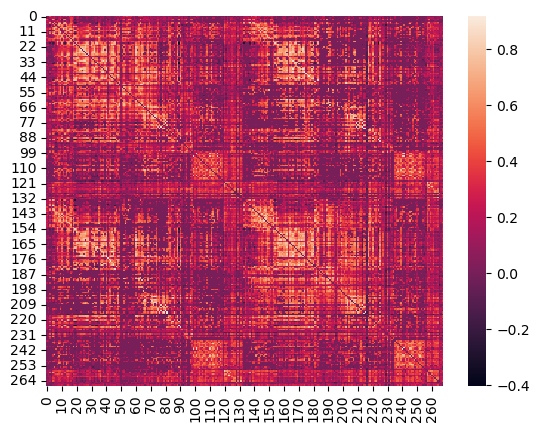

In [37]:
sns.heatmap(foo)

In [38]:
swp, dl, dc = SWP(foo)

In [39]:
swp

np.float64(0.5935444852144292)